## Design and Engineer features to feed into different models

Features designed around information available BEFORE a movie is released. The goal of the model is to attempt to predict the domestic box office revenue of a movie with information available pre-release


## Feature list

1.   Budget
2.   Runtime
3.   Release month
4.   Release season
5.   Number of genres
6.   Genre (one hot)
7.   Adult ?
8.   Director popularity (Avg revenue of previous movies)
9.   Director experience (# of movies directed)
10.  Main actor popularity (Avg revenue of previous movies)
11.  Average cast popularity (Avg revenue of previous movies for all      actors)
12.  Is franchise ?
13.  Franchise number
14.  Is sequel ?
15.  Franchise success (Avg revenue of previous movies in franchise)
16.  Number of writers
17.  Movies released that week
18.  Avg revenue of movies released that week (excluding given movie)
19.  Average revenue of movie Language


## Datasets used

1.   TMDb dataset (https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/data)
2.   The Movies dataset: movies_metadata.csv, credits.csv (https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data?select=movies_metadata.csv)

In [1]:
## Import required packages

import pandas as pd
import numpy as np
import ast
from collections import defaultdict
from sklearn.preprocessing import MultiLabelBinarizer

In [5]:
## Load datasets

df_movies = pd.read_csv('data/TMDB_movie_dataset_v11.csv')
df_credits = pd.read_csv('data/credits.csv', engine="python", quotechar='"')
df_extra_revenue = pd.read_csv('data/movie_revenue_budget_2059.csv')
df_coll = pd.read_csv('data/movies_metadata.csv')

/var/folders/0x/hppw3g0x4cx9p24g0qyvtrch0000gn/T/ipykernel_17136/3930723866.py:6: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_coll = pd.read_csv('data/movies_metadata.csv')


In [6]:
## Convert collections to workable data structure

df_coll['belongs_to_collection'] = df_coll['belongs_to_collection'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else None
)
df_coll['belongs_to_collection'] = df_coll['belongs_to_collection'].apply(
    lambda x: {'id': x['id'], 'name': x['name']} if isinstance(x, dict) else None
)
df_coll = df_coll.dropna(subset=['belongs_to_collection'])

df_coll = df_coll[['id', 'belongs_to_collection']]


In [7]:
## Merge all datasets together

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_credits['id'] = pd.to_numeric(df_credits['id'], errors='coerce')

merged_df = df_credits.merge(
    df_movies,
    left_on='id',
    right_on='id',
    how='inner'
)

df_coll['id'] = pd.to_numeric(df_coll['id'], errors='coerce')

merged_df = merged_df.merge(
    df_coll,
    left_on='id',
    right_on='id',
    how='left'
)

In [9]:
## Convert extra revenue to numerical values

df_extra_revenue['revenue'] = (df_extra_revenue['revenue']
    .str.replace('[$,]', '', regex=True)
    .str.strip()
    .replace('-', '0')
    .astype(float)
    .astype(int))
df_extra_revenue['budget'] = df_extra_revenue['budget'].fillna('0').str.replace('[$,]', '', regex=True).str.strip().replace('-', '0').astype(float).astype(int)

In [10]:
## Add extra revenue into main df where revenue is missing

extra_rows = 0

for idx, row in merged_df.iterrows():
    if row['revenue'] == 0:
        match = df_extra_revenue[df_extra_revenue['movieId'] == row['id']]
        if not match.empty and match.iloc[0]['revenue'] > 0:
            merged_df.loc[idx, 'revenue'] = match.iloc[0]['revenue']
            merged_df.loc[idx, 'budget']  = match.iloc[0]['budget']
            extra_rows += 1

print("total extra rows: ", extra_rows)

total extra rows:  85


In [11]:
## Drop unnecessary rows and columns

df = merged_df[merged_df['revenue'] > 0]
df = df.drop(columns=['vote_average', 'vote_count',
                      'status', 'backdrop_path', 'homepage',
                      'imdb_id', 'overview', 'poster_path', 'tagline',
                      'keywords'])

print(df.info())

<class 'pandas.DataFrame'>
Index: 10411 entries, 0 to 44978
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cast                   10411 non-null  str    
 1   crew                   10411 non-null  str    
 2   id                     10411 non-null  int64  
 3   title                  10411 non-null  str    
 4   release_date           10411 non-null  str    
 5   revenue                10411 non-null  int64  
 6   runtime                10411 non-null  int64  
 7   adult                  10411 non-null  bool   
 8   budget                 10411 non-null  int64  
 9   original_language      10411 non-null  str    
 10  original_title         10411 non-null  str    
 11  popularity             10411 non-null  float64
 12  genres                 10405 non-null  str    
 13  production_companies   10178 non-null  str    
 14  production_countries   10306 non-null  str    
 15  spoken_languages  

## Modify features into useable metrics for models

In [12]:
## Convert and sort by release date, helps later on when calculating features using only data from previous movies

df['release_date'] = pd.to_datetime(df['release_date'])
df = df.sort_values('release_date')

In [13]:
## Extract release season
#   Summer: June 1 to Aug 31
#   Holiday: Dec 1 to Dec 31
#   Halloween: Oct 1 to Nov 7


def add_release_seasons(df):
    month = df['month']
    day = df['release_date'].dt.day

    df['is_summer'] = (
        ((month == 6) & (day >= 1)) |
        (month == 7) |
        ((month == 8) & (day <= 31))
    ).astype(int)

    df['is_holiday'] = (
        (month == 12)
    ).astype(int)

    df['is_halloween'] = (
        ((month == 10) & (day >= 1)) |
        ((month == 11) & (day <= 7))
    ).astype(int)

    return df

df['month'] = df['release_date'].dt.month
df = add_release_seasons(df)

In [14]:
## Genres
#   Count number of genres
#   One hot encode all 19 unique genres

def parse_genres(x):
    if pd.isna(x):
        return []
    return [g.strip() for g in x.split(',')]

df['genre_list'] = df['genres'].apply(parse_genres)
df['num_genres'] = df['genre_list'].apply(len)


mlb = MultiLabelBinarizer()

genre_dummies = pd.DataFrame(
    mlb.fit_transform(df['genre_list']),
    columns=mlb.classes_,
    index=df.index
)

genre_dummies.columns = [col.replace(" ", "_") for col in genre_dummies.columns]
df = pd.concat([df, genre_dummies], axis=1)

In [19]:
## Convert adult to 1 or 0, 1 being adult film and 0 being not

df['adult'] = df['adult'].astype(int)

In [20]:
## Extract the director for each movie

def get_director(crew_str):
    if pd.isna(crew_str) or crew_str == '':
        return None
    try:
        crew_list = ast.literal_eval(crew_str)
        for member in crew_list:
            if member.get('job') == 'Director':
                return member.get('name')
    except:
        return None
    return None

df['director'] = df['crew'].apply(get_director)

In [21]:
## Compute director popularity and experience
#   Director popularity: Average revenue of all PREVIOUS films
#       - For directors with no previous movies, set popularity to 0
#   Director experience: Number of movies previously directed


director_history = {}
director_popularity = []
director_experience = []

for row in df.itertuples():
    director = row.director

    if director is None or director not in director_history:
        director_popularity.append(0)
        director_experience.append(0)
        if director:
            director_history[director] = [row.revenue]
    else:
        past_revenue = director_history[director]
        director_popularity.append(np.mean(past_revenue))
        director_experience.append(len(past_revenue))

        director_history[director].append(row.revenue)

df['director_popularity'] = director_popularity
df['director_experience'] = director_experience

In [23]:
## Extract cast list to a workable data structure

def parse_cast(x):
    try:
        return [actor['name'] for actor in ast.literal_eval(x)]
    except:
        return []

df['cast_list'] = df['cast'].apply(parse_cast)

In [24]:
## Find main actor for each film and calculate the popularity for that actor
#   Main actor: first actor in cast list
#   Main actor popularity: Average revenue of all PREVIOUS films
#       - For actors with no previous films, set popularity to 0

def get_actor_avg_revenue(df, actor_name, cutoff_date):
    cutoff_date = pd.to_datetime(cutoff_date)

    filtered = df[df['release_date'] < cutoff_date]

    actor_movies = filtered[
        filtered['cast_list'].apply(lambda x: actor_name in x)
    ]

    if len(actor_movies) == 0:
        return 0

    return actor_movies['revenue'].mean()


df['main_actor'] = df['cast_list'].apply(lambda x: x[0] if len(x) > 0 else None)

main_actor_popularity = []

for row in df.itertuples():
    actor = row.main_actor
    date = row.release_date

    if actor is None or pd.isna(date):
        main_actor_popularity.append(0)
    else:
        avg_rev = get_actor_avg_revenue(df, actor, date)
        main_actor_popularity.append(avg_rev)

df['main_actor_popularity'] = main_actor_popularity

In [26]:
## Compute average popularity for all cast
#   Cast popularity: Average average revenue of all previous films of all actors

actor_history = defaultdict(list)
actor_popularity = []

for row in df.itertuples():
    actors = row.cast_list

    past_avgs = [
        np.mean(actor_history[a])
        for a in actors if actor_history[a]
    ]
    actor_popularity.append(np.mean(past_avgs) if past_avgs else 0)

    for a in actors:
        actor_history[a].append(row.revenue)

df['actor_popularity'] = actor_popularity

In [28]:
## Deal with franchise features
#   Is franchise: 1 is movie belongs to a collection, 0 if not
#   Franchise number: Number within franchise, 1 if not in a collection
#   Is sequel: 1 is movie is number 2 in franchise, 0 if not
#   Franchise success: Average revenue of all movies in the franchise, computed from all previous movies in franchise

df['collection_id'] = df['belongs_to_collection'].apply(
    lambda x: x['id'] if isinstance(x, dict) else None
)


df['is_franchise'] = df['belongs_to_collection'].notna().astype(int)


df['franchise_number'] = df.groupby('collection_id').cumcount() + 1
df.loc[df['collection_id'].isna(), 'franchise_number'] = 1
df['franchise_number'] = df['franchise_number'].astype(int)


df['is_sequel'] = (df['franchise_number'] == 2).astype(int)



df['franchise_success'] = (
    df.groupby('collection_id')['revenue']
    .transform(lambda x: x.shift().expanding().mean())
)
df['franchise_success'] = df['franchise_success'].fillna(0)

In [29]:
## Compute number of writer from crew

df['crew'] = df['crew'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['num_writers'] = df['crew'].apply(lambda crew: sum(1 for person in crew if person.get('department') == 'Writing'))

In [30]:
## Compute the number of movies coming out that week (-1 to exclude itself)

df['release_year'] = df['release_date'].dt.isocalendar().year
df['release_week'] = df['release_date'].dt.isocalendar().week
df['movies_per_week'] = (
    df.groupby(['release_year', 'release_week'])['id']
    .transform('count')
)

df['other_movies_same_week'] = df['movies_per_week'] - 1

In [31]:
## Computer average revenue for each language

lang_mean = df.groupby('original_language')['revenue'].mean()

df['language_avg_revenue'] = df['original_language'].map(lang_mean)

## Data organization and analysis

In [55]:
## Organize all features plus target columns, revenue

revenue_and_feature_list = df[['revenue', 'budget', 'runtime', 'month', 'is_summer', 'is_holiday', 'is_halloween', 'num_genres',
        'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family',
        'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science_Fiction',
        'TV_Movie', 'Thriller', 'War', 'Western', 'adult', 'director_popularity', 'director_experience',
        'main_actor_popularity', 'actor_popularity', 'is_franchise', 'franchise_number', 'is_sequel', 'franchise_success',
        'num_writers', 'other_movies_same_week', 'language_avg_revenue'
]]

print(revenue_and_feature_list.shape)

(10411, 39)


In [56]:
## Log scale all columns using revenue data to account for skew

revenue_and_feature_list['revenue'] = np.log1p(revenue_and_feature_list['revenue'])
revenue_and_feature_list['budget'] = np.log1p(revenue_and_feature_list['budget'])
revenue_and_feature_list['director_popularity'] = np.log1p(revenue_and_feature_list['director_popularity'])
revenue_and_feature_list['main_actor_popularity'] = np.log1p(revenue_and_feature_list['main_actor_popularity'])
revenue_and_feature_list['actor_popularity'] = np.log1p(revenue_and_feature_list['actor_popularity'])
revenue_and_feature_list['franchise_success'] = np.log1p(revenue_and_feature_list['franchise_success'])
revenue_and_feature_list['language_avg_revenue'] = np.log1p(revenue_and_feature_list['language_avg_revenue'])

In [46]:
revenue_and_feature_list = revenue_and_feature_list.drop(columns='adult')

In [57]:
## Save file

revenue_and_feature_list.to_csv('data/engineered_features_scaled.csv', index=False)

In [52]:
## Extract target from features

X = revenue_and_feature_list.drop(columns='revenue')
y = revenue_and_feature_list['revenue']

In [53]:
correlation = X.corrwith(y).sort_values(ascending=False)
print(correlation)

budget                    0.514125
director_popularity       0.358999
actor_popularity          0.289404
main_actor_popularity     0.268581
is_franchise              0.257360
num_writers               0.242249
runtime                   0.225554
director_experience       0.223564
franchise_success         0.213578
Adventure                 0.209893
language_avg_revenue      0.209367
num_genres                0.200332
Action                    0.169069
Family                    0.143130
franchise_number          0.137232
Fantasy                   0.126874
is_sequel                 0.117937
Animation                 0.097773
Science_Fiction           0.090055
is_holiday                0.089330
is_summer                 0.061113
Comedy                    0.049534
Thriller                  0.042320
month                     0.031361
Crime                     0.018561
Mystery                   0.013777
War                       0.011639
History                   0.010078
Romance             

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


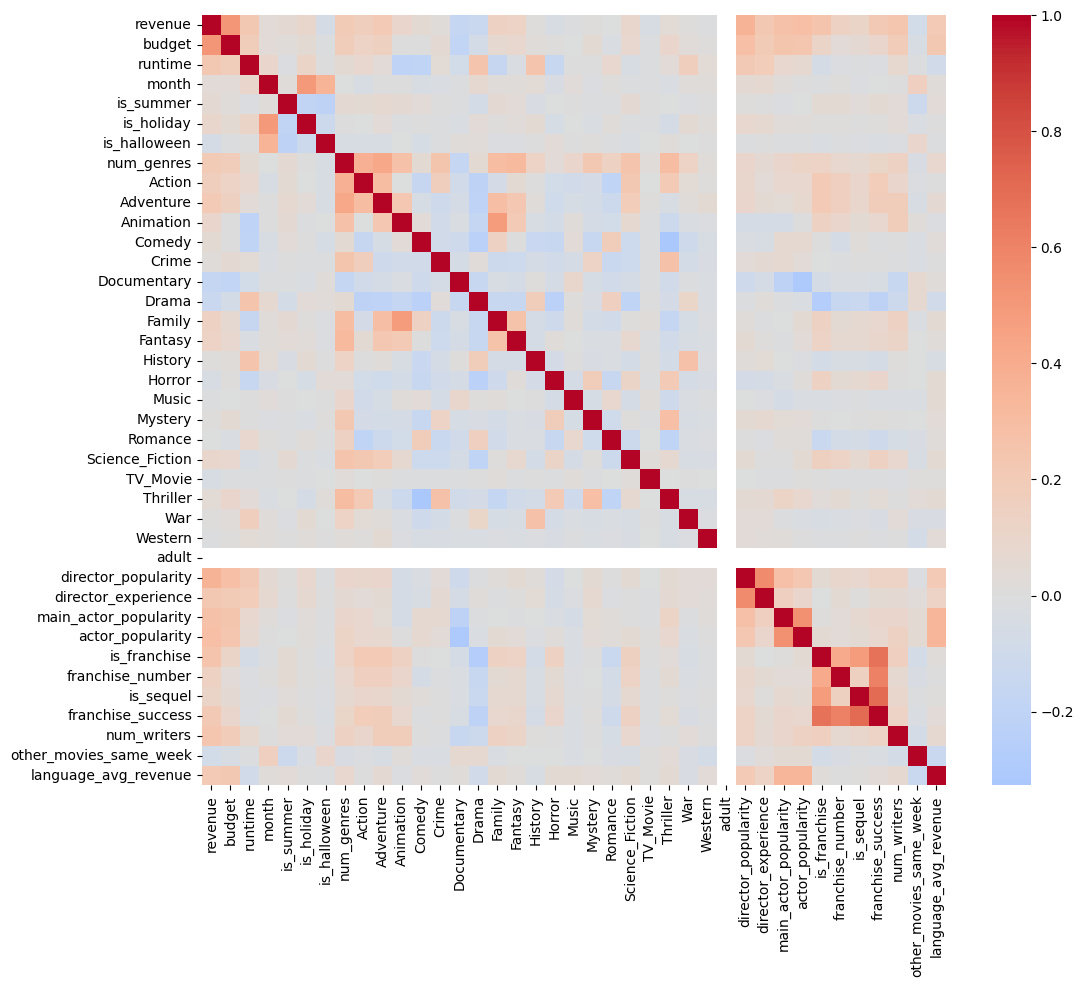

In [54]:
corr = revenue_and_feature_list.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()